# House Prices Regression: Predicting Property Prices with Interpretable Machine Learning

## Business Context

This project builds and evaluates regression models to estimate residential property sale prices based on structural, location, quality, and condition-related features.

The goal is not only to predict prices, but also to understand model stability, analyze prediction errors, and interpret the variables associated with property value.

## Main Questions

1. Which models predict house prices more accurately?
2. Is the best model stable across validation folds?
3. Where does the model make the largest errors?
4. Which property characteristics are most strongly associated with price?
5. What are the limitations of this regression approach?

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
model_metrics = pd.read_csv(REPORTS_DIR / "model_metrics.csv")
cv_summary = pd.read_csv(REPORTS_DIR / "cross_validation_summary.csv")
final_model_selection = pd.read_csv(REPORTS_DIR / "final_model_selection.csv")
validation_predictions = pd.read_csv(REPORTS_DIR / "validation_predictions.csv")
ridge_coefficients = pd.read_csv(REPORTS_DIR / "ridge_feature_coefficients.csv")

model_metrics

,model,mae,rmse,r2
0,linear_regression,"15,074.8672","22,906.5087",0.9316
1,ridge_regression,"16,434.8220","25,110.0597",0.9178
2,lasso_regression,"16,328.3020","25,122.6499",0.9177
3,random_forest,"17,349.9650","29,673.7369",0.8852
4,baseline_median,"59,568.2500","88,667.1675",-0.0250


In [3]:
model_metrics.sort_values("rmse")

,model,mae,rmse,r2
0,linear_regression,"15,074.8672","22,906.5087",0.9316
1,ridge_regression,"16,434.8220","25,110.0597",0.9178
2,lasso_regression,"16,328.3020","25,122.6499",0.9177
3,random_forest,"17,349.9650","29,673.7369",0.8852
4,baseline_median,"59,568.2500","88,667.1675",-0.0250


## Single Validation Split Results

Linear Regression achieved the lowest RMSE on the initial validation split. However, a single split can be unstable, especially with a small dataset and many one-hot encoded categorical variables.

For this reason, model selection should not rely only on this result.

In [4]:
cv_summary.sort_values("rmse_mean")

,model,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
0,random_forest,"17,580.2718","1,364.6193","30,537.3038","6,119.1974",0.8508,0.0412
1,ridge_regression,"16,634.5511","2,025.5141","43,337.8072","36,656.6382",0.5981,0.6062
2,lasso_regression,"16,392.8802","2,553.5237","45,883.6305","42,185.1409",0.5240,0.7626
3,linear_regression,"17,380.0829","3,368.7309","52,687.8319","49,190.8169",0.3637,1.0199
4,baseline_median,"55,624.8618","2,478.7411","81,317.9230","5,639.7297",-0.0565,0.0309


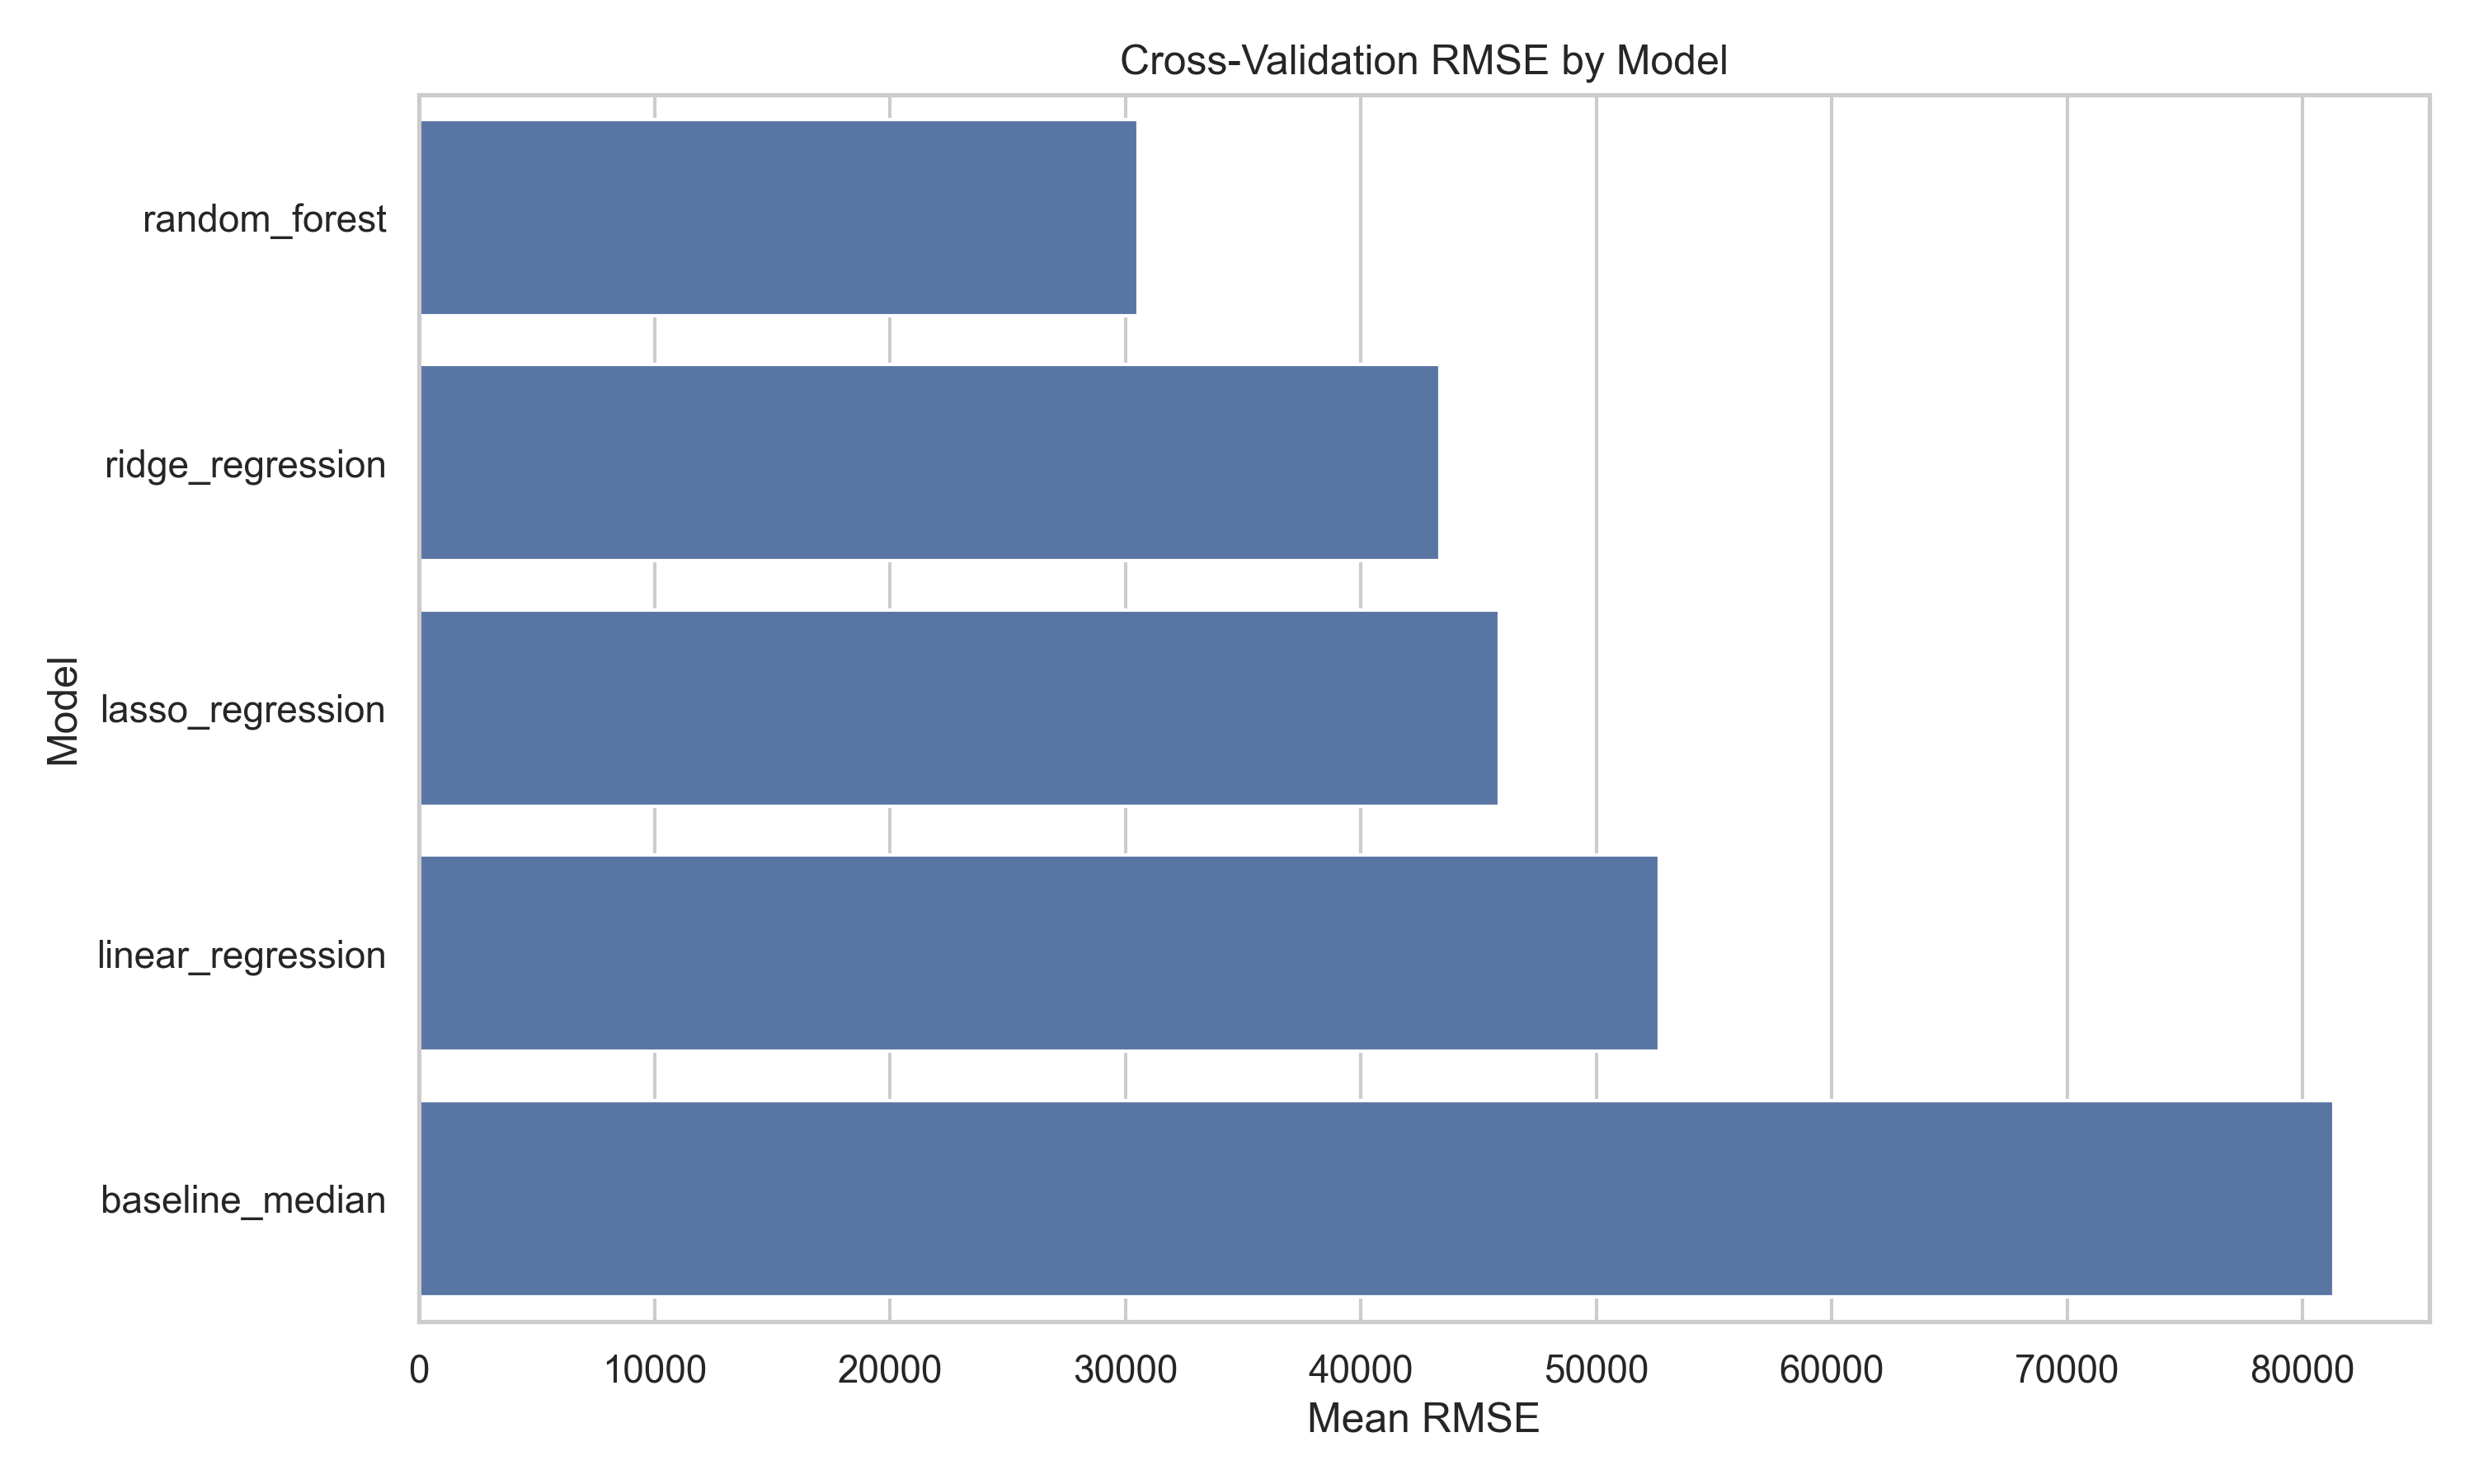

In [5]:
display(Image(filename=FIGURES_DIR / "cross_validation_rmse_by_model.png"))

## Cross-Validation Results

Cross-validation changed the model selection decision.

Although Linear Regression performed best on the single validation split, Random Forest achieved the best average RMSE across 5 folds and showed better stability than the linear models.

This suggests that Linear Regression was sensitive to the specific validation split, while Random Forest provided more robust predictive performance.

In [6]:
final_model_selection

,validation_best_model,final_selected_model,selection_reason
0,linear_regression,random_forest,Random Forest was selected as the final predic...


## Final Model Decision

The final predictive model is **Random Forest**.

The decision is based on cross-validation stability, not only on the best result from a single validation split.

Ridge Regression is still used for interpretation because regularized linear coefficients are easier to explain than Random Forest internal structure.

In [7]:
validation_predictions[["actual_price", "predicted_price", "residual", "absolute_error", "absolute_percentage_error"]].describe()

,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error
count,292.0000,292.0000,292.0000,292.0000,292.0000
mean,"178,839.8116","175,314.3614","3,525.4503","17,349.9650",10.1914
std,"87,730.7513","72,275.5607","29,514.1496","24,114.3280",13.6138
min,"35,311.0000","60,149.3556","-113,842.3704",7.3358,0.0059
25%,"127,000.0000","124,473.3318","-9,122.9433","4,497.9120",2.6151
50%,"154,150.0000","154,264.5812",678.4586,"9,980.2346",6.2921
75%,"209,175.0000","204,140.0711","11,219.7712","22,025.2155",12.4417
max,"755,000.0000","523,850.2177","231,149.7823","231,149.7823",133.5840


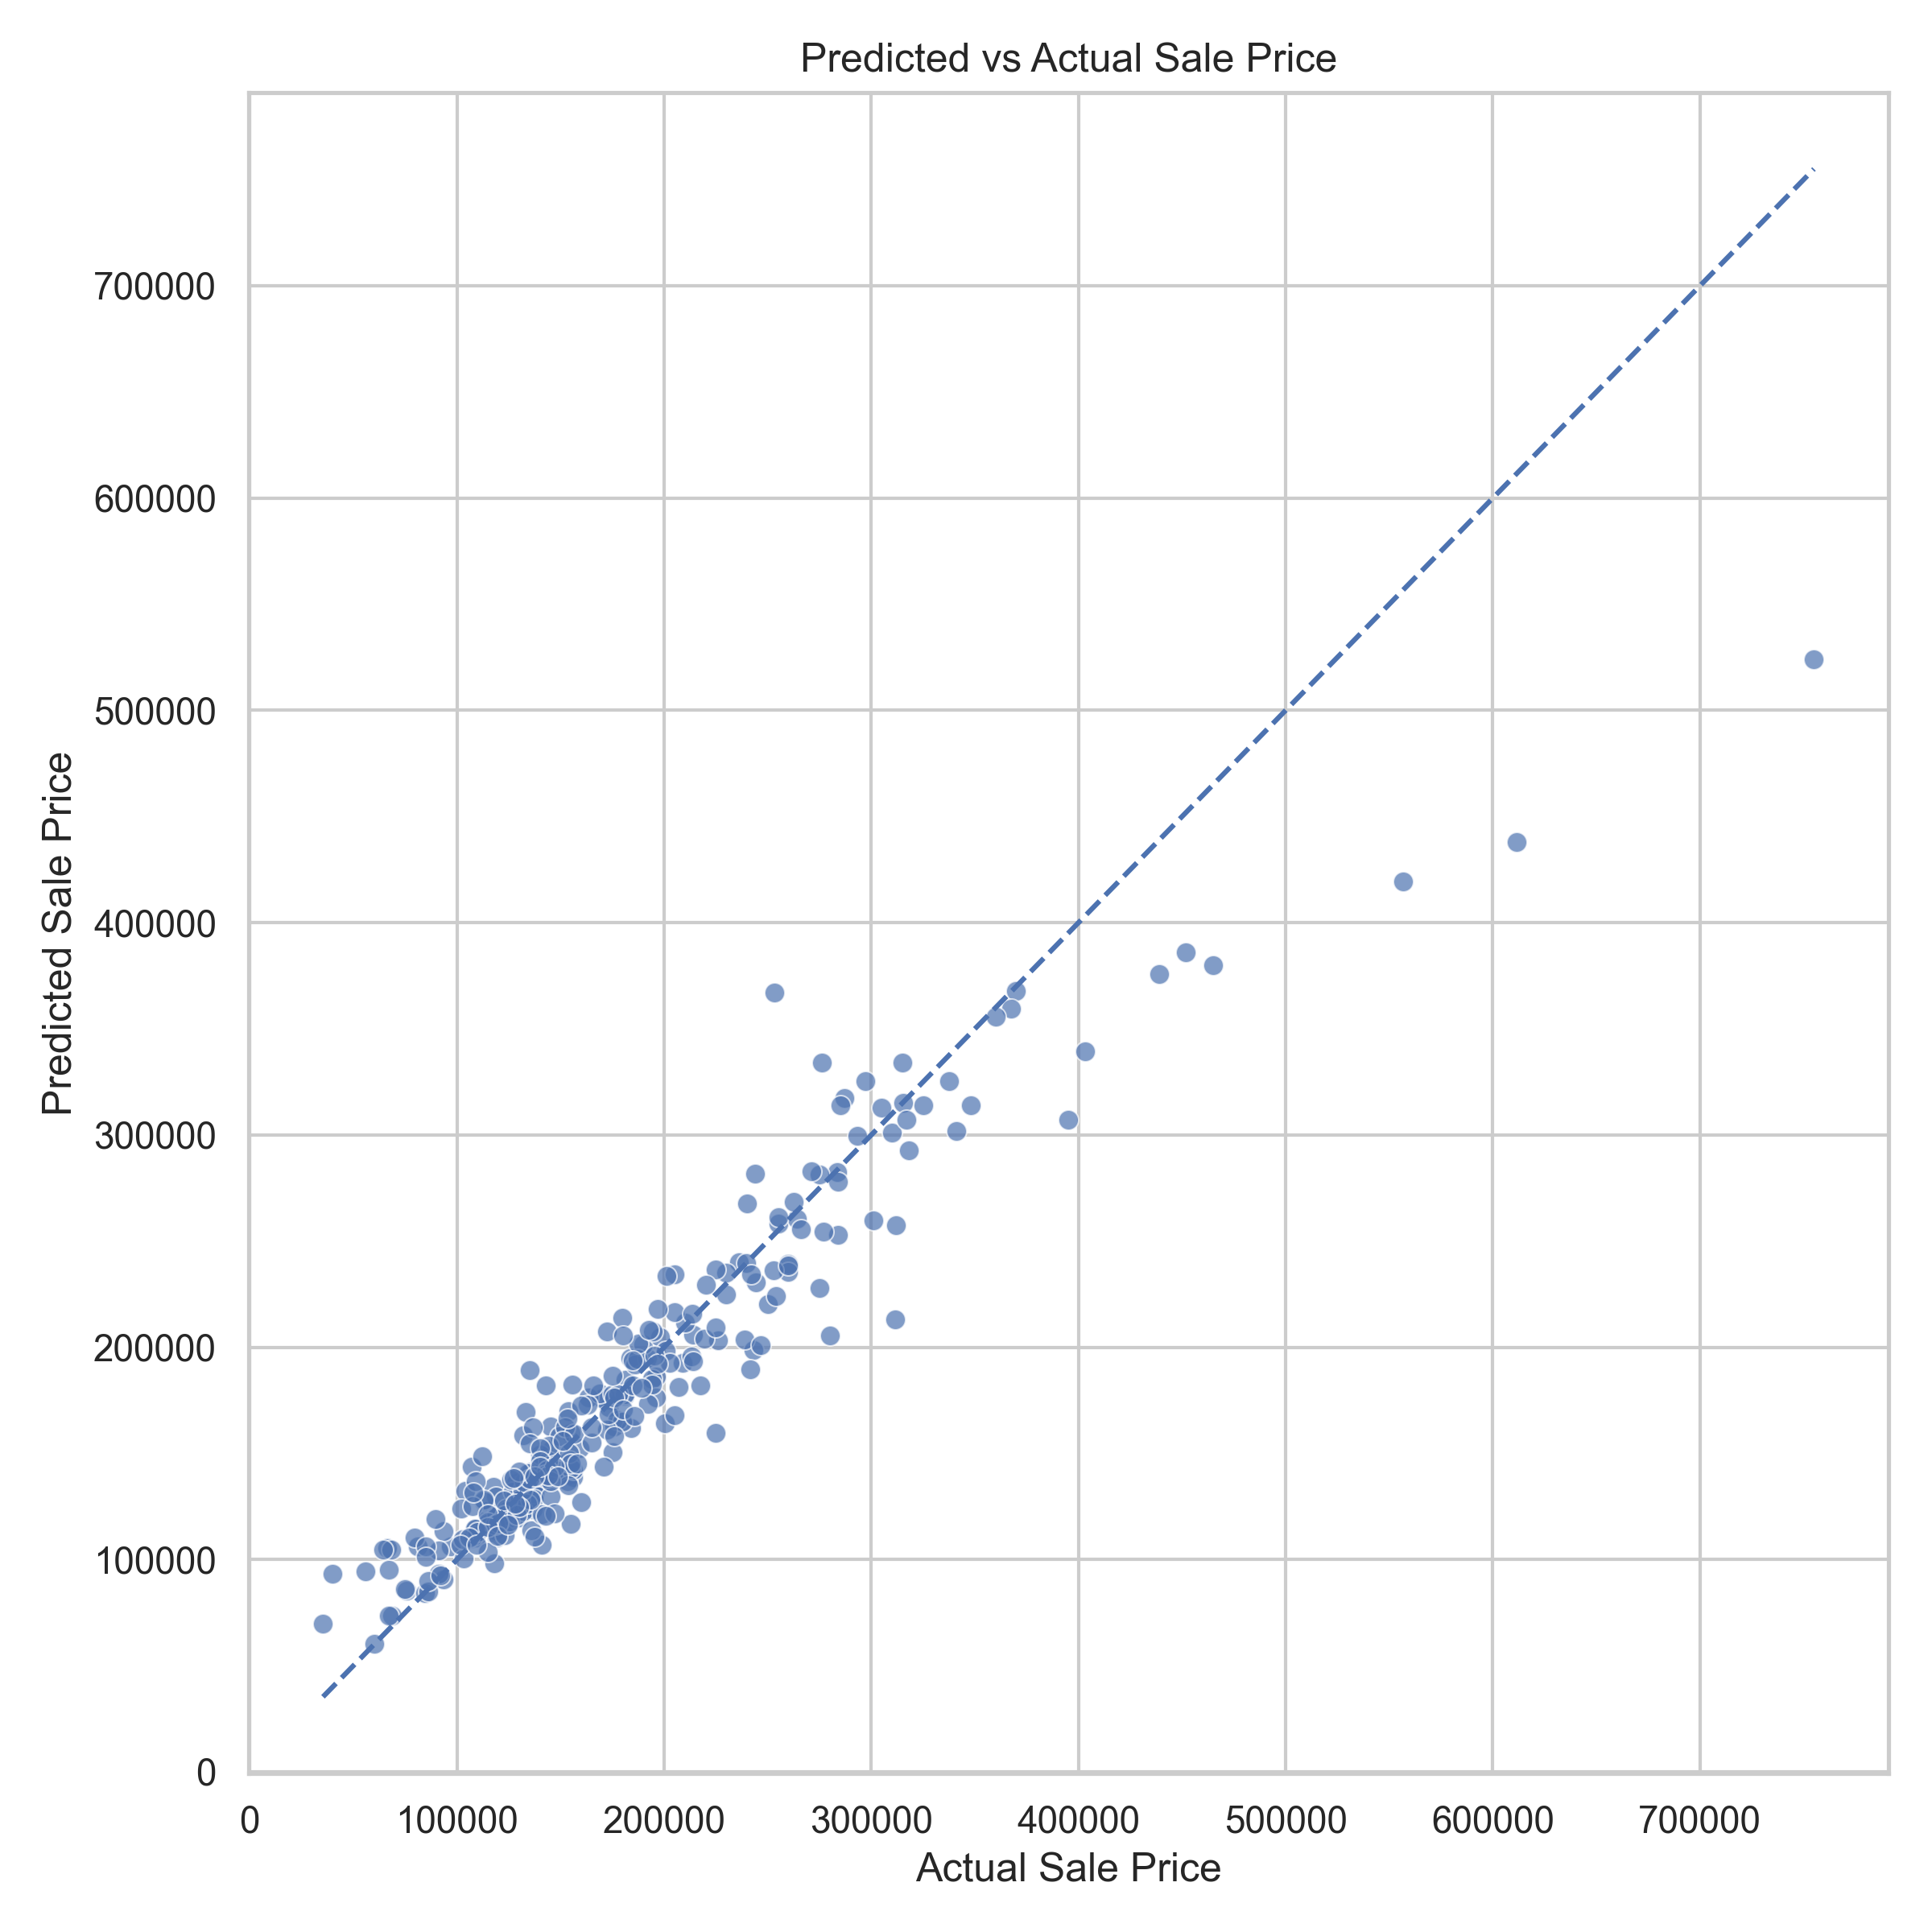

In [8]:
display(Image(filename=FIGURES_DIR / "predicted_vs_actual.png"))

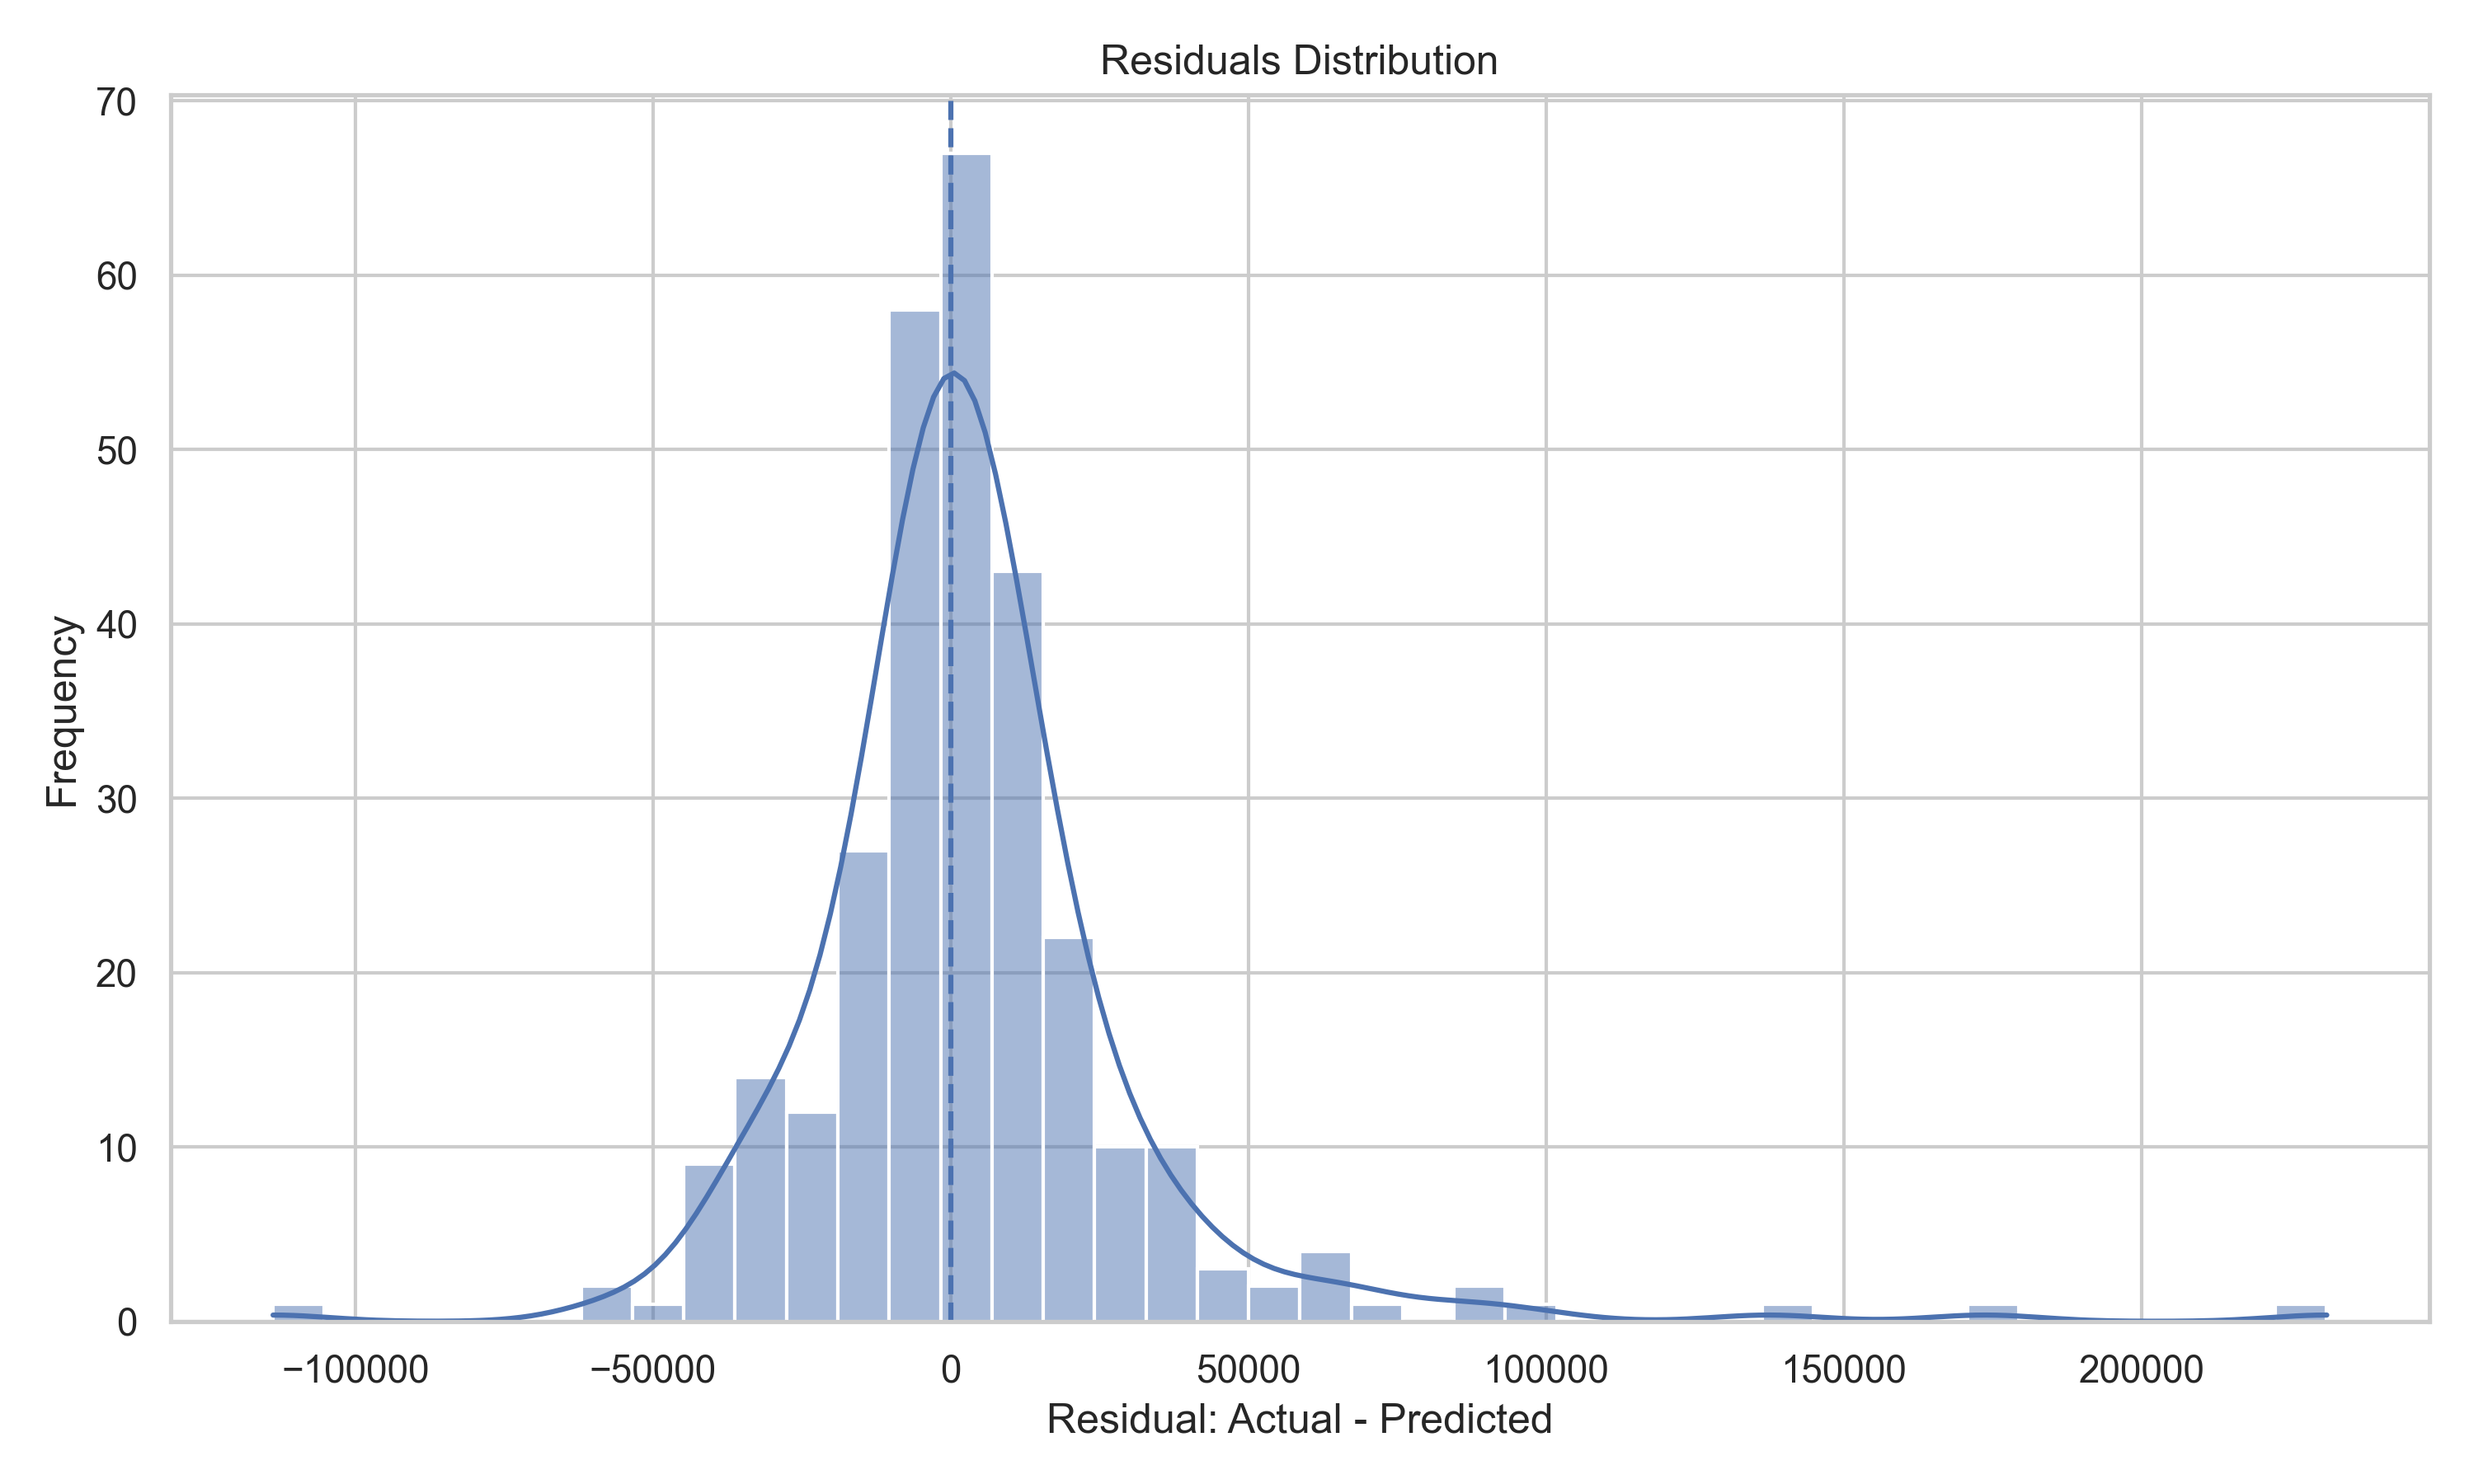

In [9]:
display(Image(filename=FIGURES_DIR / "residuals_distribution.png"))

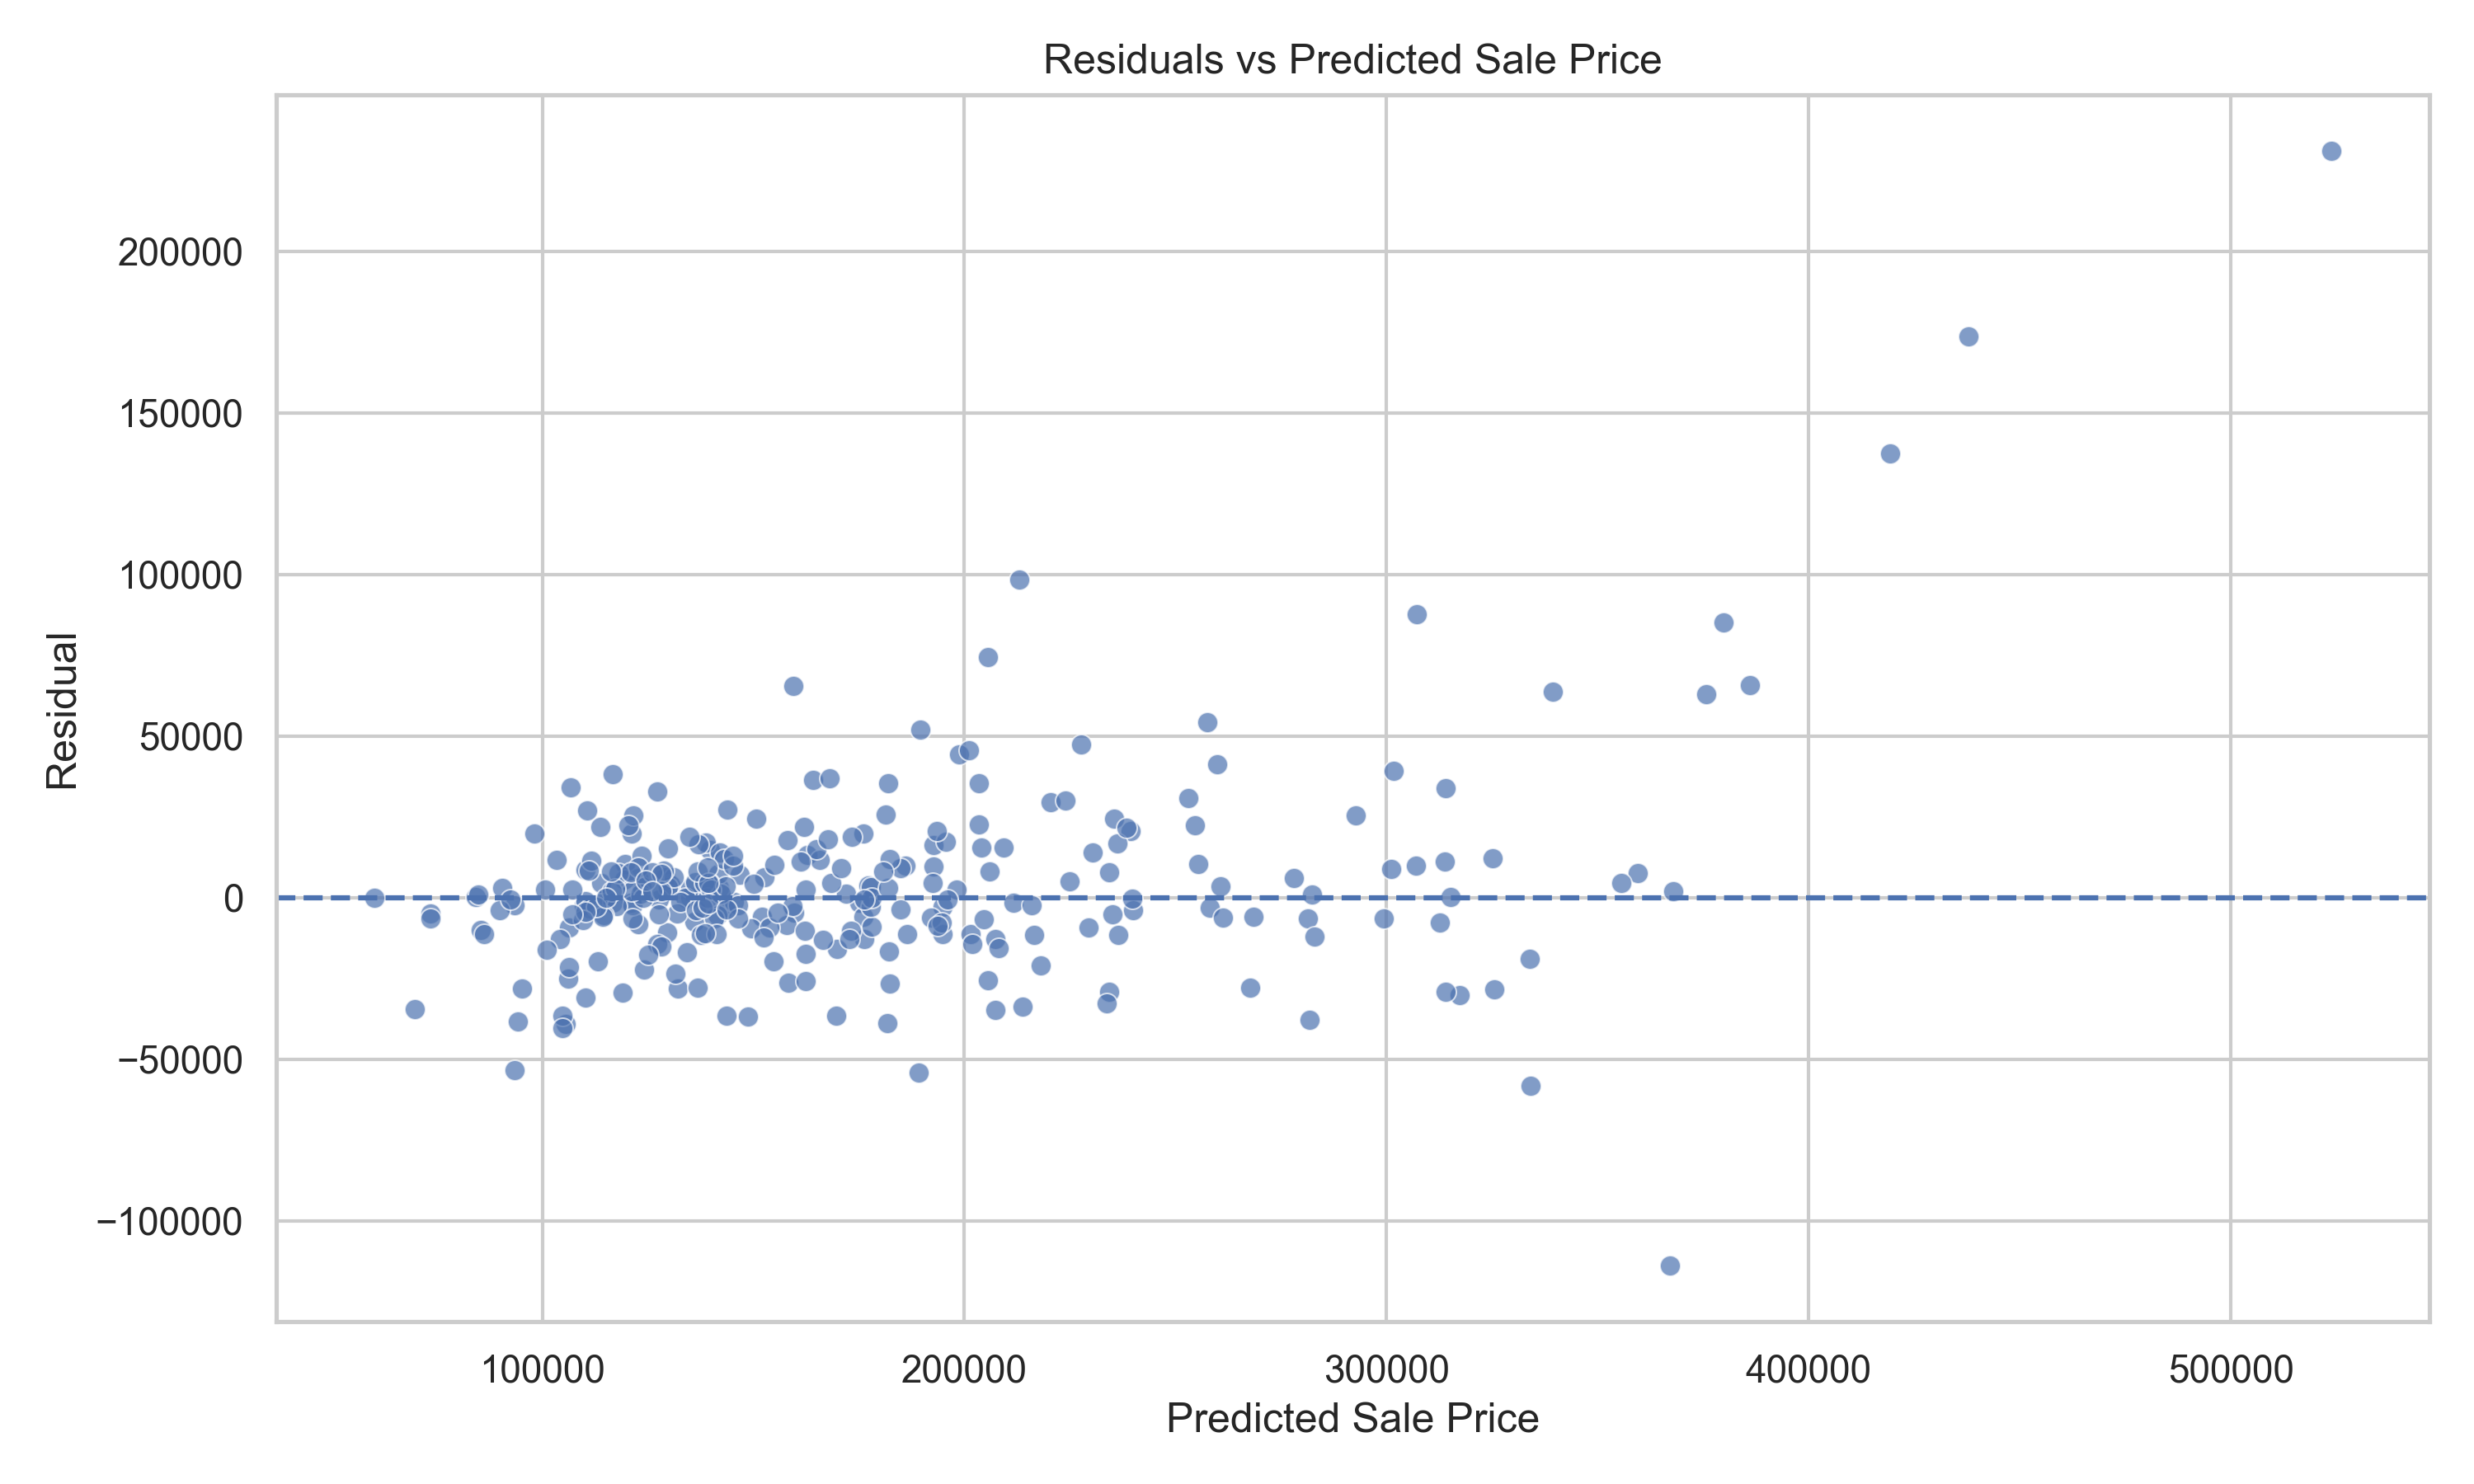

In [10]:
display(Image(filename=FIGURES_DIR / "residuals_vs_predicted.png"))

## Validation Error Analysis

The final Random Forest model achieved:

- MAE: approximately 17.35K
- RMSE: approximately 29.67K
- R²: approximately 0.885
- Median absolute error: approximately 9.98K
- Median absolute percentage error: approximately 6.29%

The difference between MAE and RMSE indicates that a relatively small number of large prediction errors increases the overall error.

In [11]:
top_errors = (
    validation_predictions
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

top_errors

,Id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error
139,692,755000,"523,850.2177","231,149.7823","231,149.7823",30.6159
74,899,611657,"437,875.5584","173,781.4416","173,781.4416",28.4116
168,1047,556581,"419,237.5272","137,343.4728","137,343.4728",24.6763
43,582,253293,"367,135.3704","-113,842.3704","113,842.3704",44.9449
6,219,311500,"212,963.8310","98,536.1690","98,536.1690",31.6328
260,775,395000,"307,199.4868","87,800.5132","87,800.5132",22.2280
270,1244,465000,"379,767.5134","85,232.4866","85,232.4866",18.3296
200,452,280000,"205,525.9009","74,474.0991","74,474.0991",26.5979
48,592,451950,"386,102.9214","65,847.0786","65,847.0786",14.5695
195,608,225000,"159,552.4859","65,447.5141","65,447.5141",29.0878


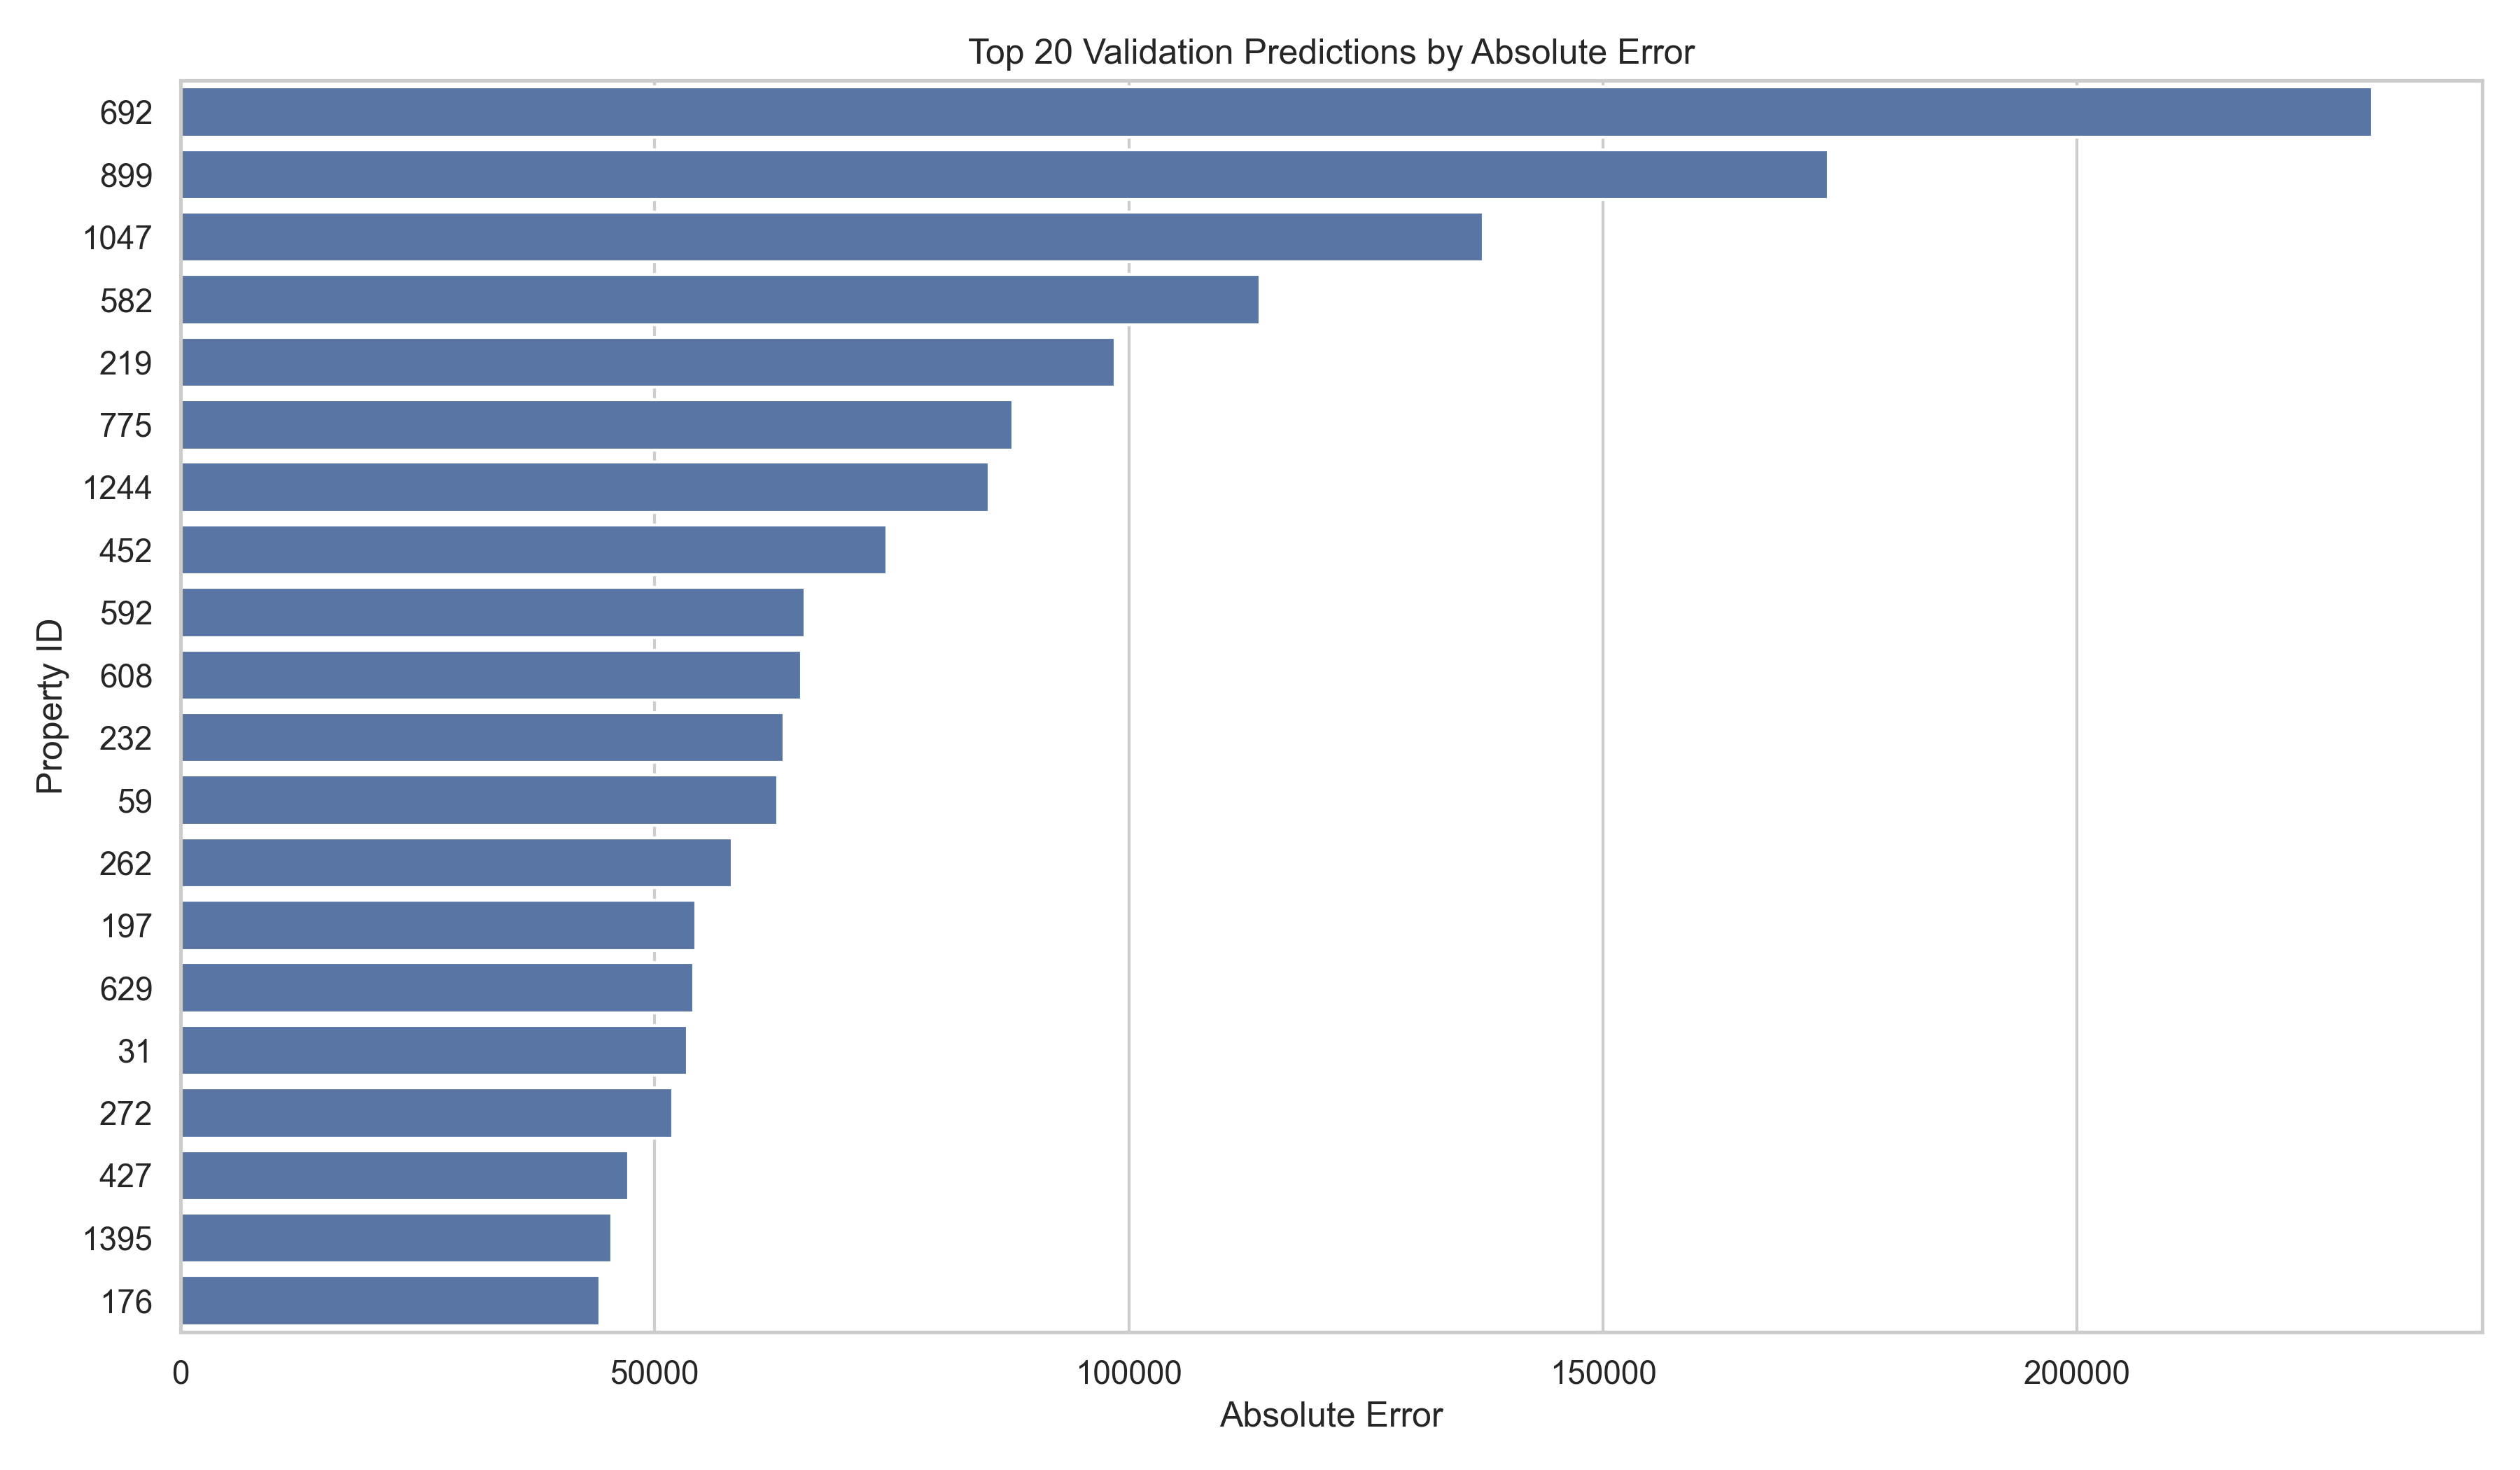

In [12]:
display(Image(filename=FIGURES_DIR / "top_20_absolute_errors.png"))

## Largest Prediction Errors

The largest errors are concentrated in higher-value or atypical properties.

This is a common limitation in housing price models: expensive or unusual properties are harder to estimate because they may depend on factors not fully captured in the dataset, such as exact location desirability, renovation quality, market timing, or luxury characteristics.

In [13]:
top_positive = (
    ridge_coefficients
    .sort_values("coefficient_log_scale", ascending=False)
    .head(15)
)

top_positive[
    ["feature", "feature_group", "coefficient_log_scale", "approx_percent_effect"]
]

,feature,feature_group,coefficient_log_scale,approx_percent_effect
1,Neighborhood_StoneBr,categorical_most_frequent,0.0929,9.7306
2,Neighborhood_Crawfor,categorical_most_frequent,0.0857,8.9492
4,OverallQual,numeric_median,0.0733,7.6056
5,Exterior1st_BrkFace,categorical_most_frequent,0.0726,7.5350
7,Neighborhood_NridgHt,categorical_most_frequent,0.0678,7.0141
8,Functional_Typ,categorical_most_frequent,0.0670,6.9250
12,GrLivArea,numeric_median,0.0588,6.0603
15,SaleCondition_Alloca,categorical_most_frequent,0.0496,5.0900
17,BsmtQual_Ex,categorical_none,0.0491,5.0281
19,BldgType_2fmCon,categorical_most_frequent,0.0458,4.6829


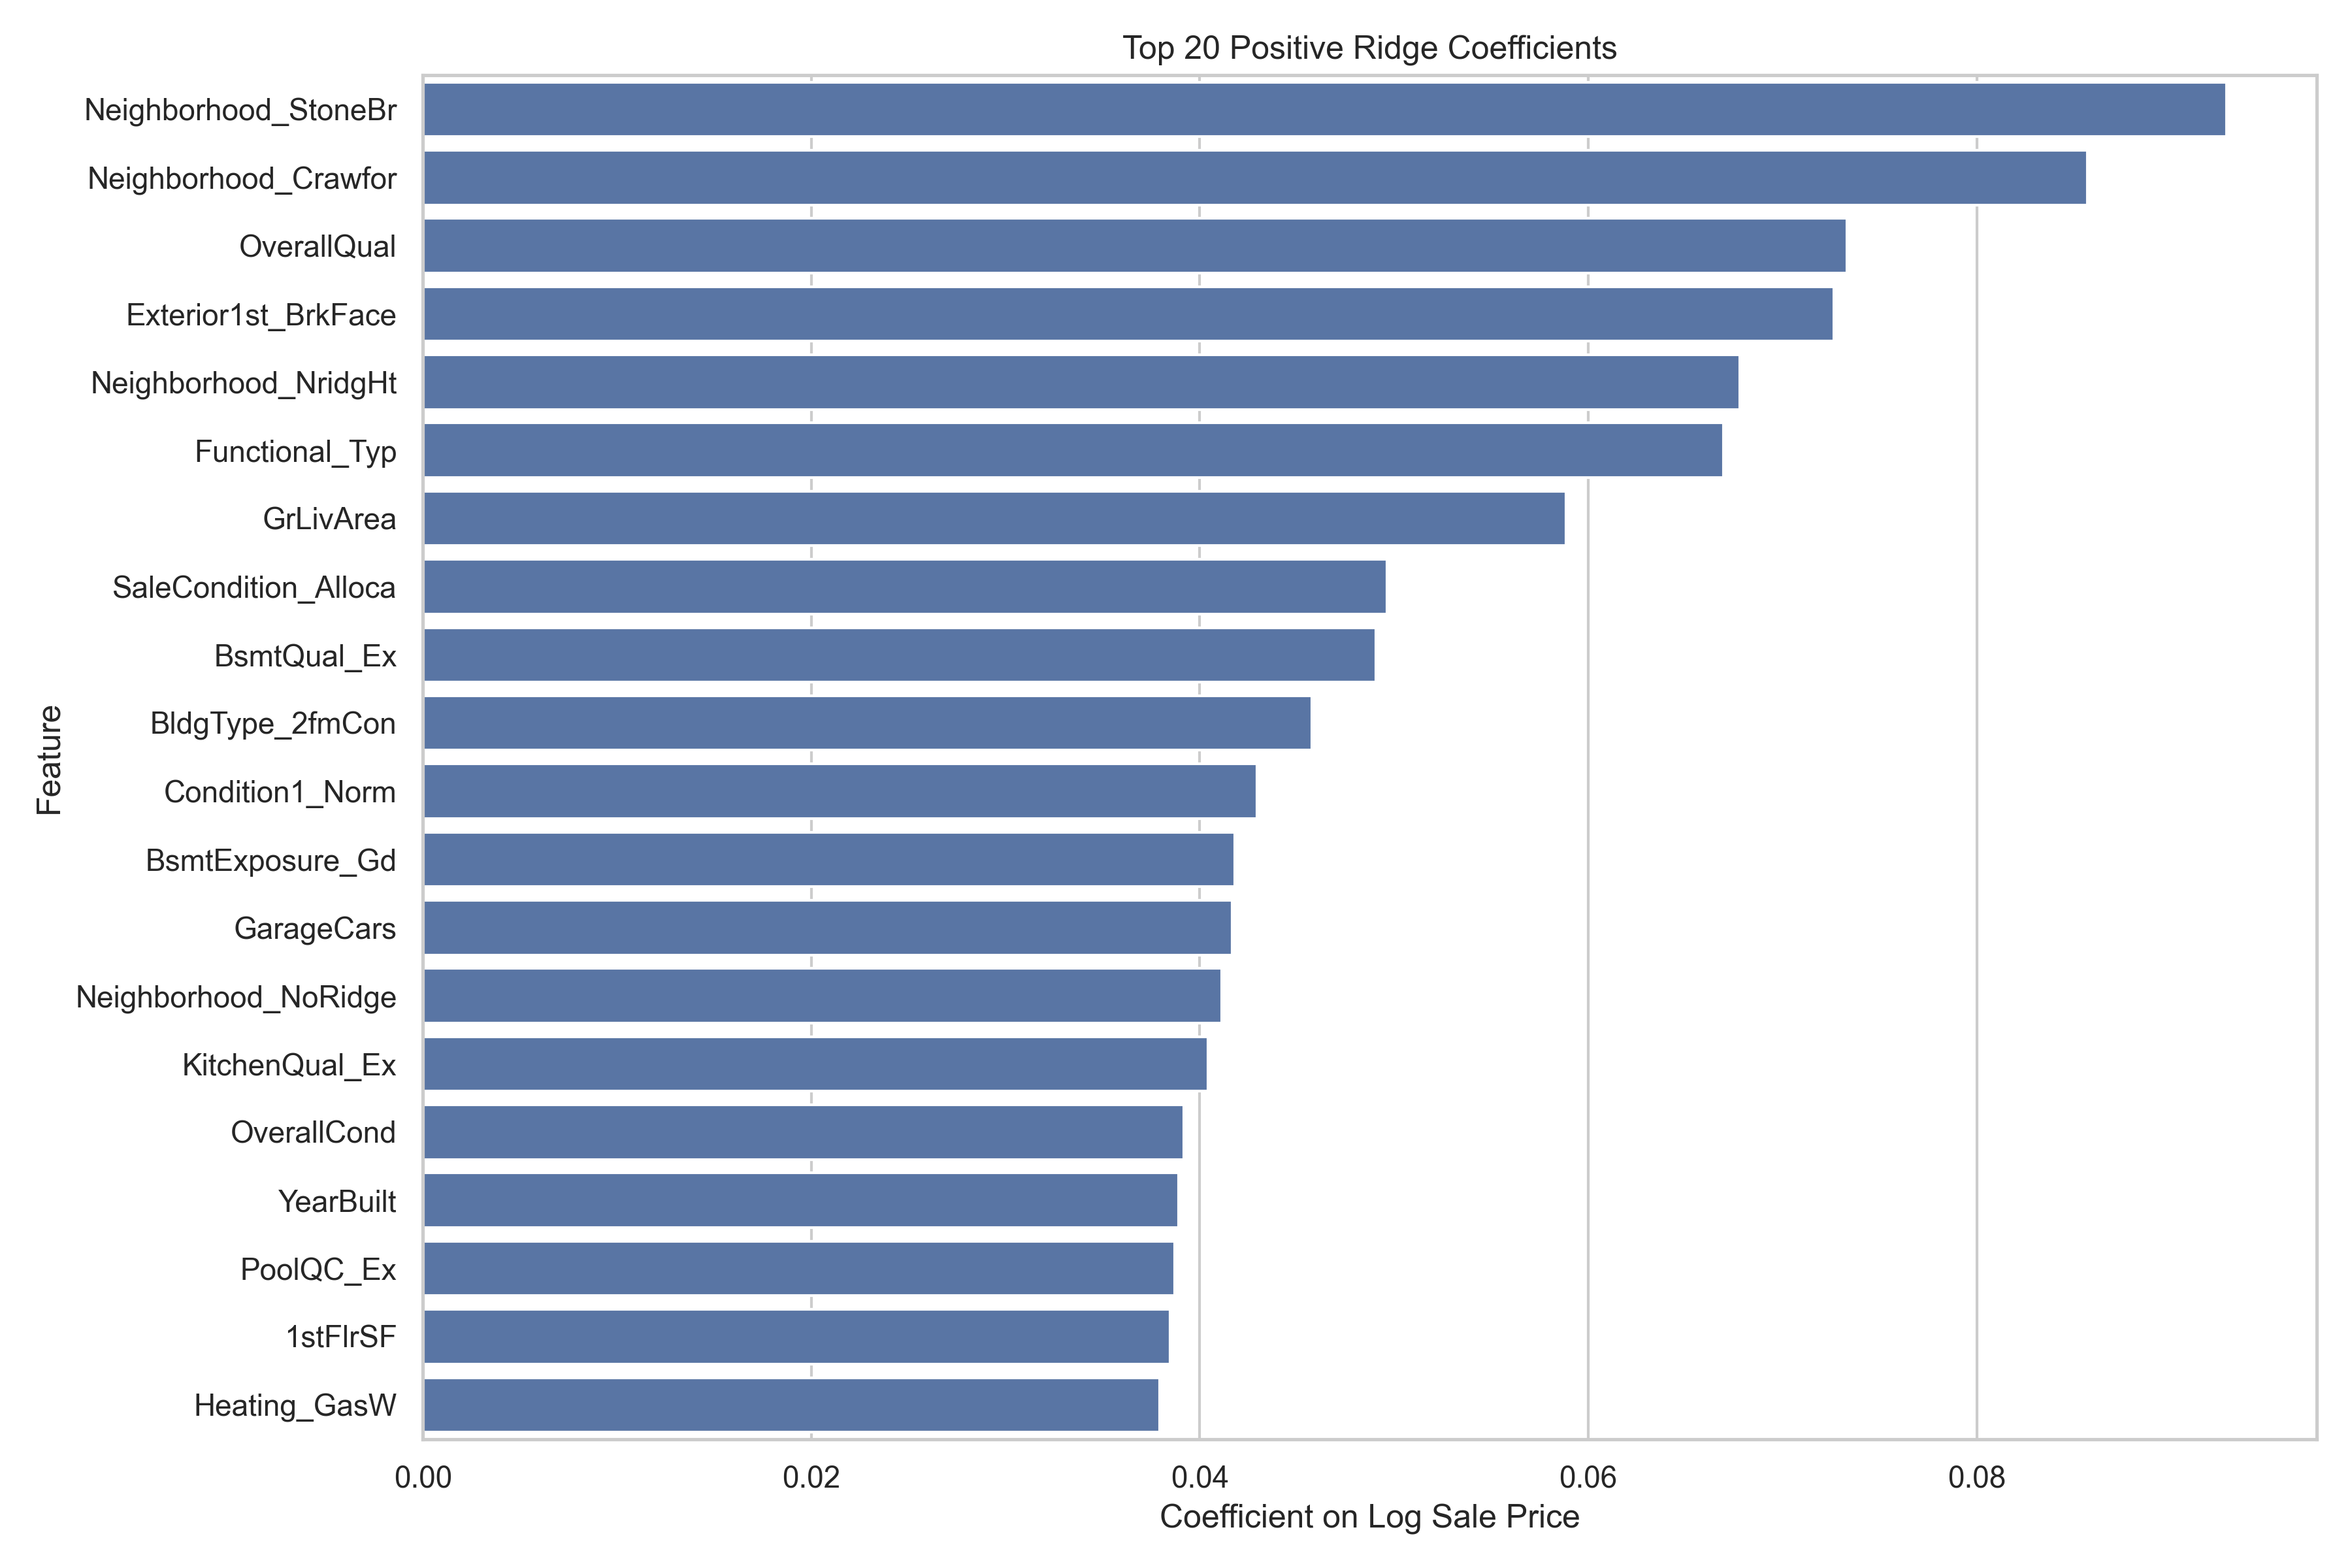

In [14]:
display(Image(filename=FIGURES_DIR / "top_positive_ridge_coefficients.png"))

## Positive Price Associations

The Ridge interpretation suggests that features such as premium neighborhoods, overall quality, above-ground living area, excellent basement quality, garage capacity, and excellent kitchen quality are positively associated with sale price.

These relationships make business sense: quality, space, location, and functional condition are major drivers of residential property value.

In [15]:
top_negative = (
    ridge_coefficients
    .sort_values("coefficient_log_scale", ascending=True)
    .head(15)
)

top_negative[
    ["feature", "feature_group", "coefficient_log_scale", "approx_percent_effect"]
]

,feature,feature_group,coefficient_log_scale,approx_percent_effect
0,RoofMatl_ClyTile,categorical_most_frequent,-0.1049,-9.9572
3,Condition2_PosN,categorical_most_frequent,-0.0822,-7.8868
6,PoolQC_Gd,categorical_none,-0.0724,-6.9817
9,Neighborhood_MeadowV,categorical_most_frequent,-0.0647,-6.2666
10,Functional_Maj2,categorical_most_frequent,-0.0634,-6.1447
11,Neighborhood_Edwards,categorical_most_frequent,-0.0615,-5.9685
13,MSZoning_C (all),categorical_most_frequent,-0.0576,-5.5997
14,LandContour_Bnk,categorical_most_frequent,-0.0571,-5.5508
16,Heating_Grav,categorical_most_frequent,-0.0493,-4.8121
18,BldgType_Twnhs,categorical_most_frequent,-0.0490,-4.7787


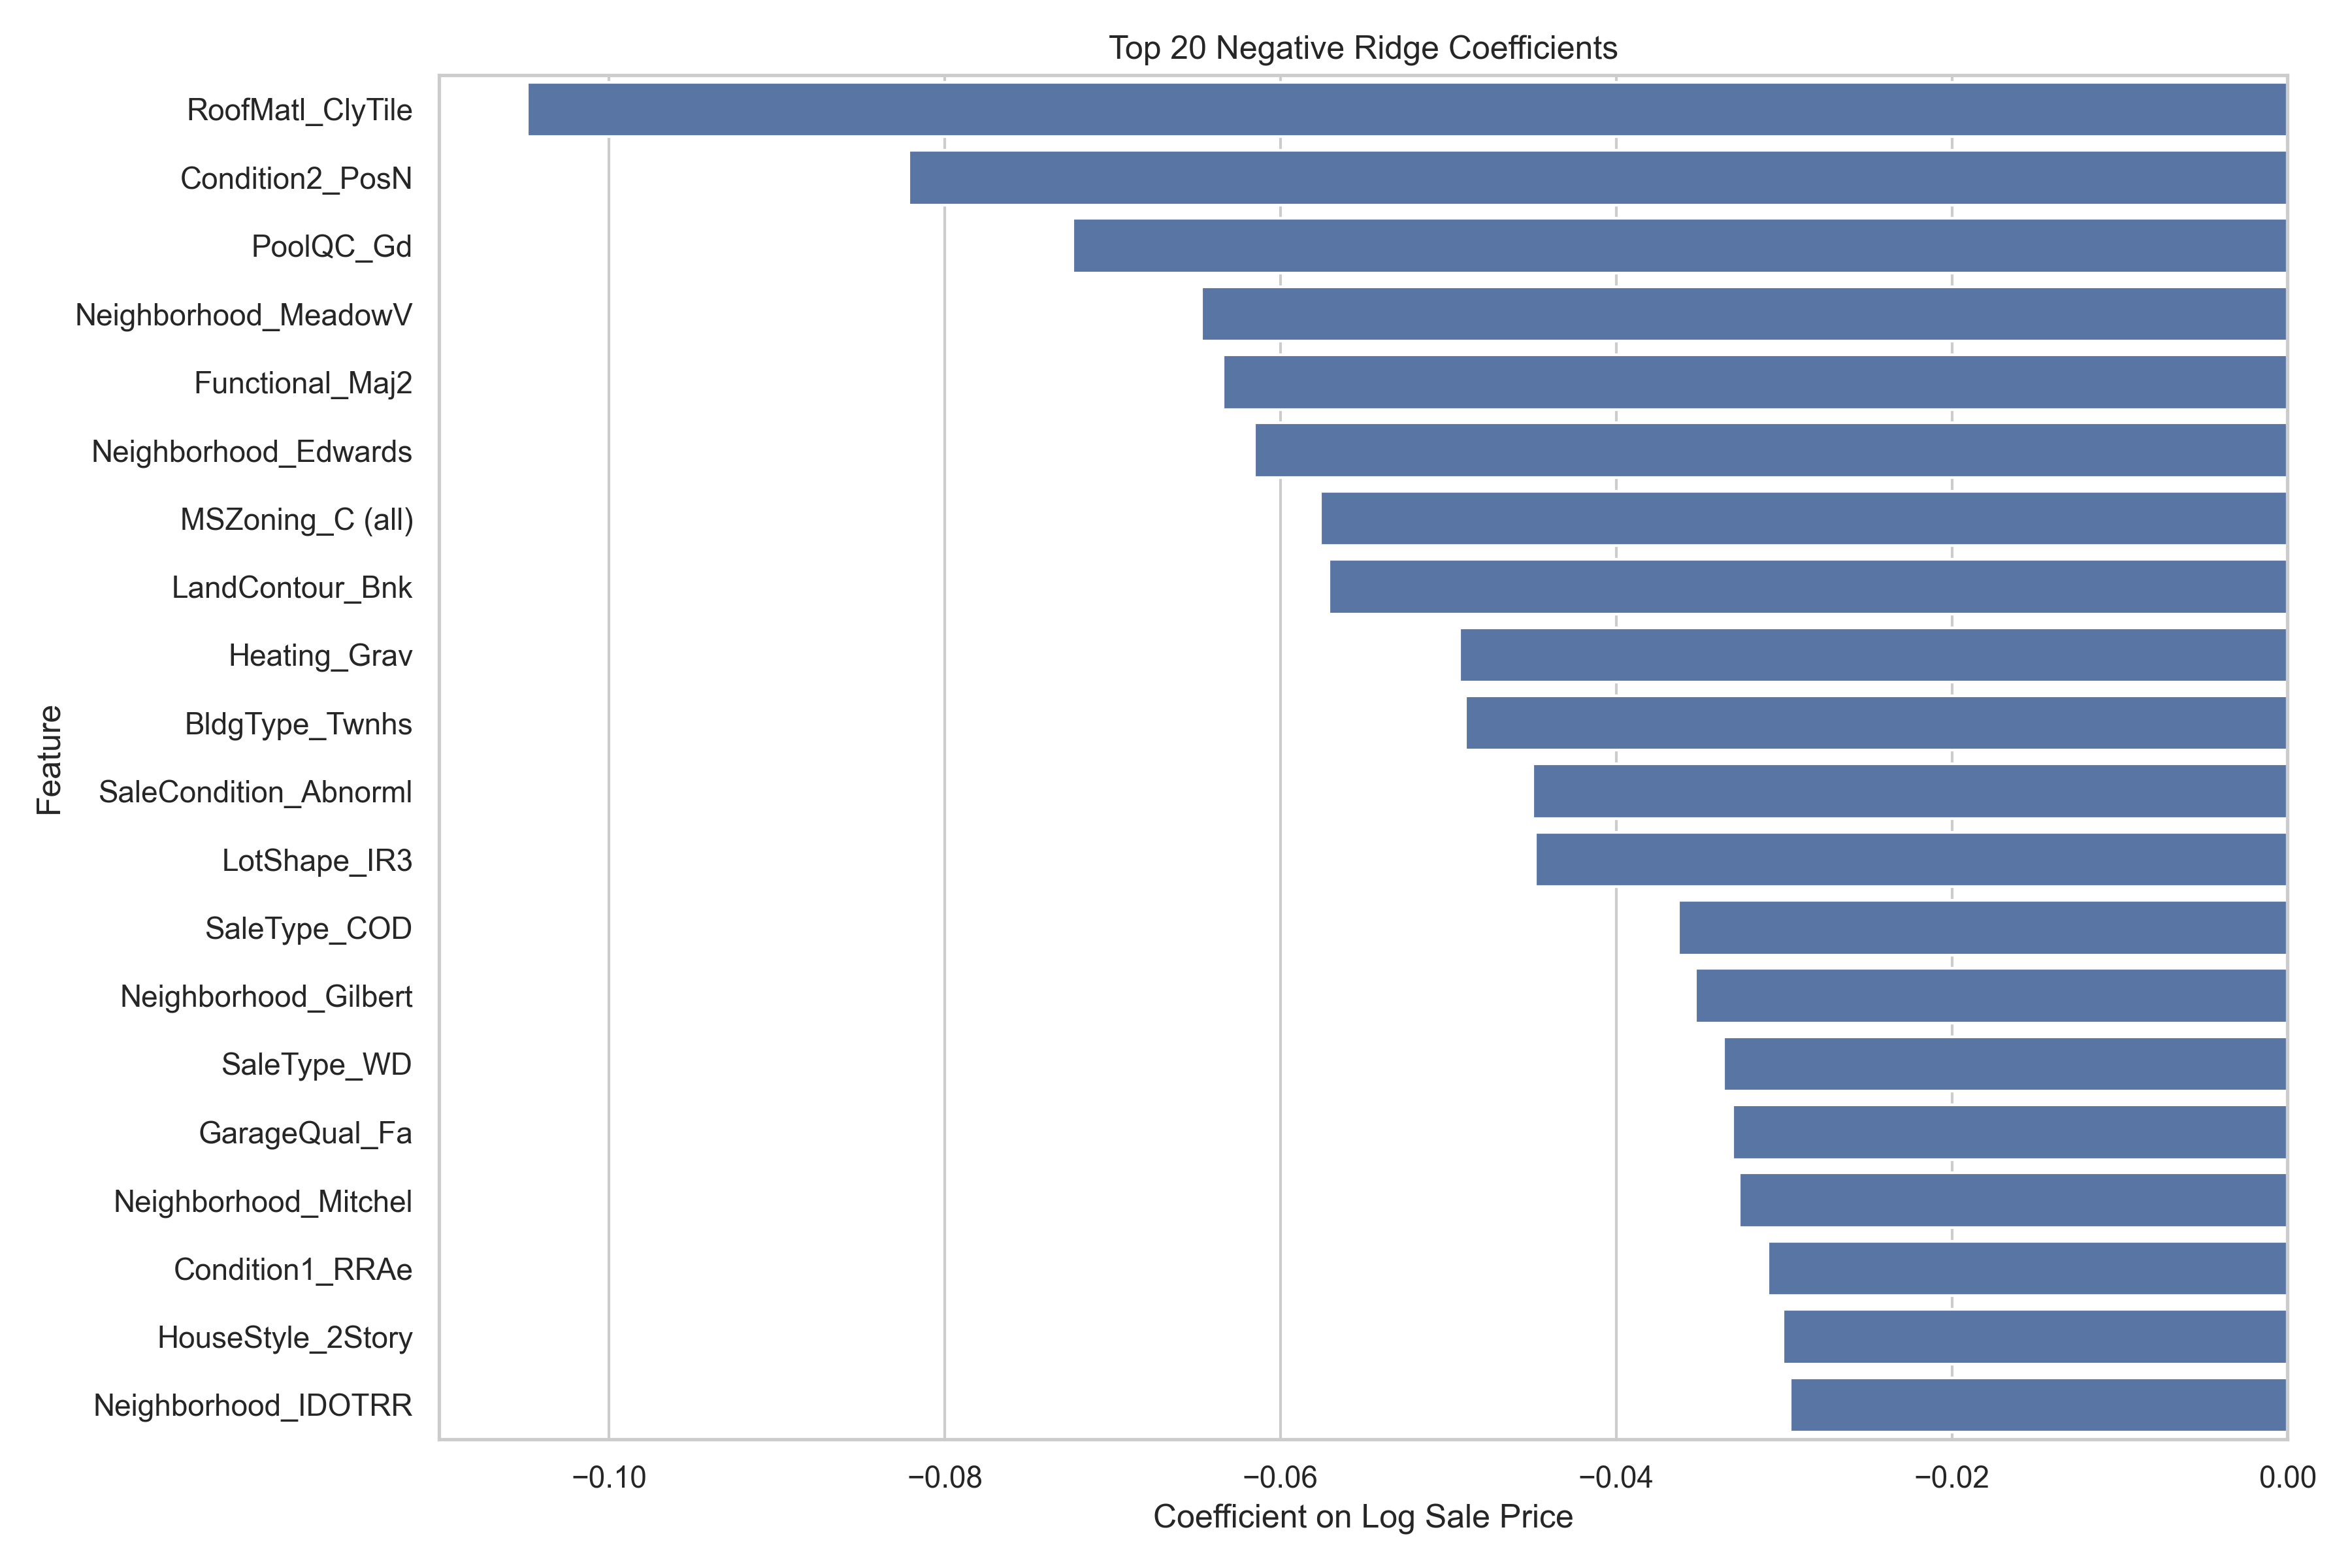

In [16]:
display(Image(filename=FIGURES_DIR / "top_negative_ridge_coefficients.png"))

## Negative Price Associations

Some negative coefficients are associated with lower-value neighborhoods, abnormal sale conditions, certain zoning categories, functional issues, and less desirable property characteristics.

These coefficients should be interpreted as associations, not causal effects. They also depend on the reference categories created during one-hot encoding.

In [17]:
ridge_coefficients.head(20)[
    ["feature", "feature_group", "coefficient_log_scale", "absolute_coefficient"]
]

,feature,feature_group,coefficient_log_scale,absolute_coefficient
0,RoofMatl_ClyTile,categorical_most_frequent,-0.1049,0.1049
1,Neighborhood_StoneBr,categorical_most_frequent,0.0929,0.0929
2,Neighborhood_Crawfor,categorical_most_frequent,0.0857,0.0857
3,Condition2_PosN,categorical_most_frequent,-0.0822,0.0822
4,OverallQual,numeric_median,0.0733,0.0733
5,Exterior1st_BrkFace,categorical_most_frequent,0.0726,0.0726
6,PoolQC_Gd,categorical_none,-0.0724,0.0724
7,Neighborhood_NridgHt,categorical_most_frequent,0.0678,0.0678
8,Functional_Typ,categorical_most_frequent,0.0670,0.0670
9,Neighborhood_MeadowV,categorical_most_frequent,-0.0647,0.0647


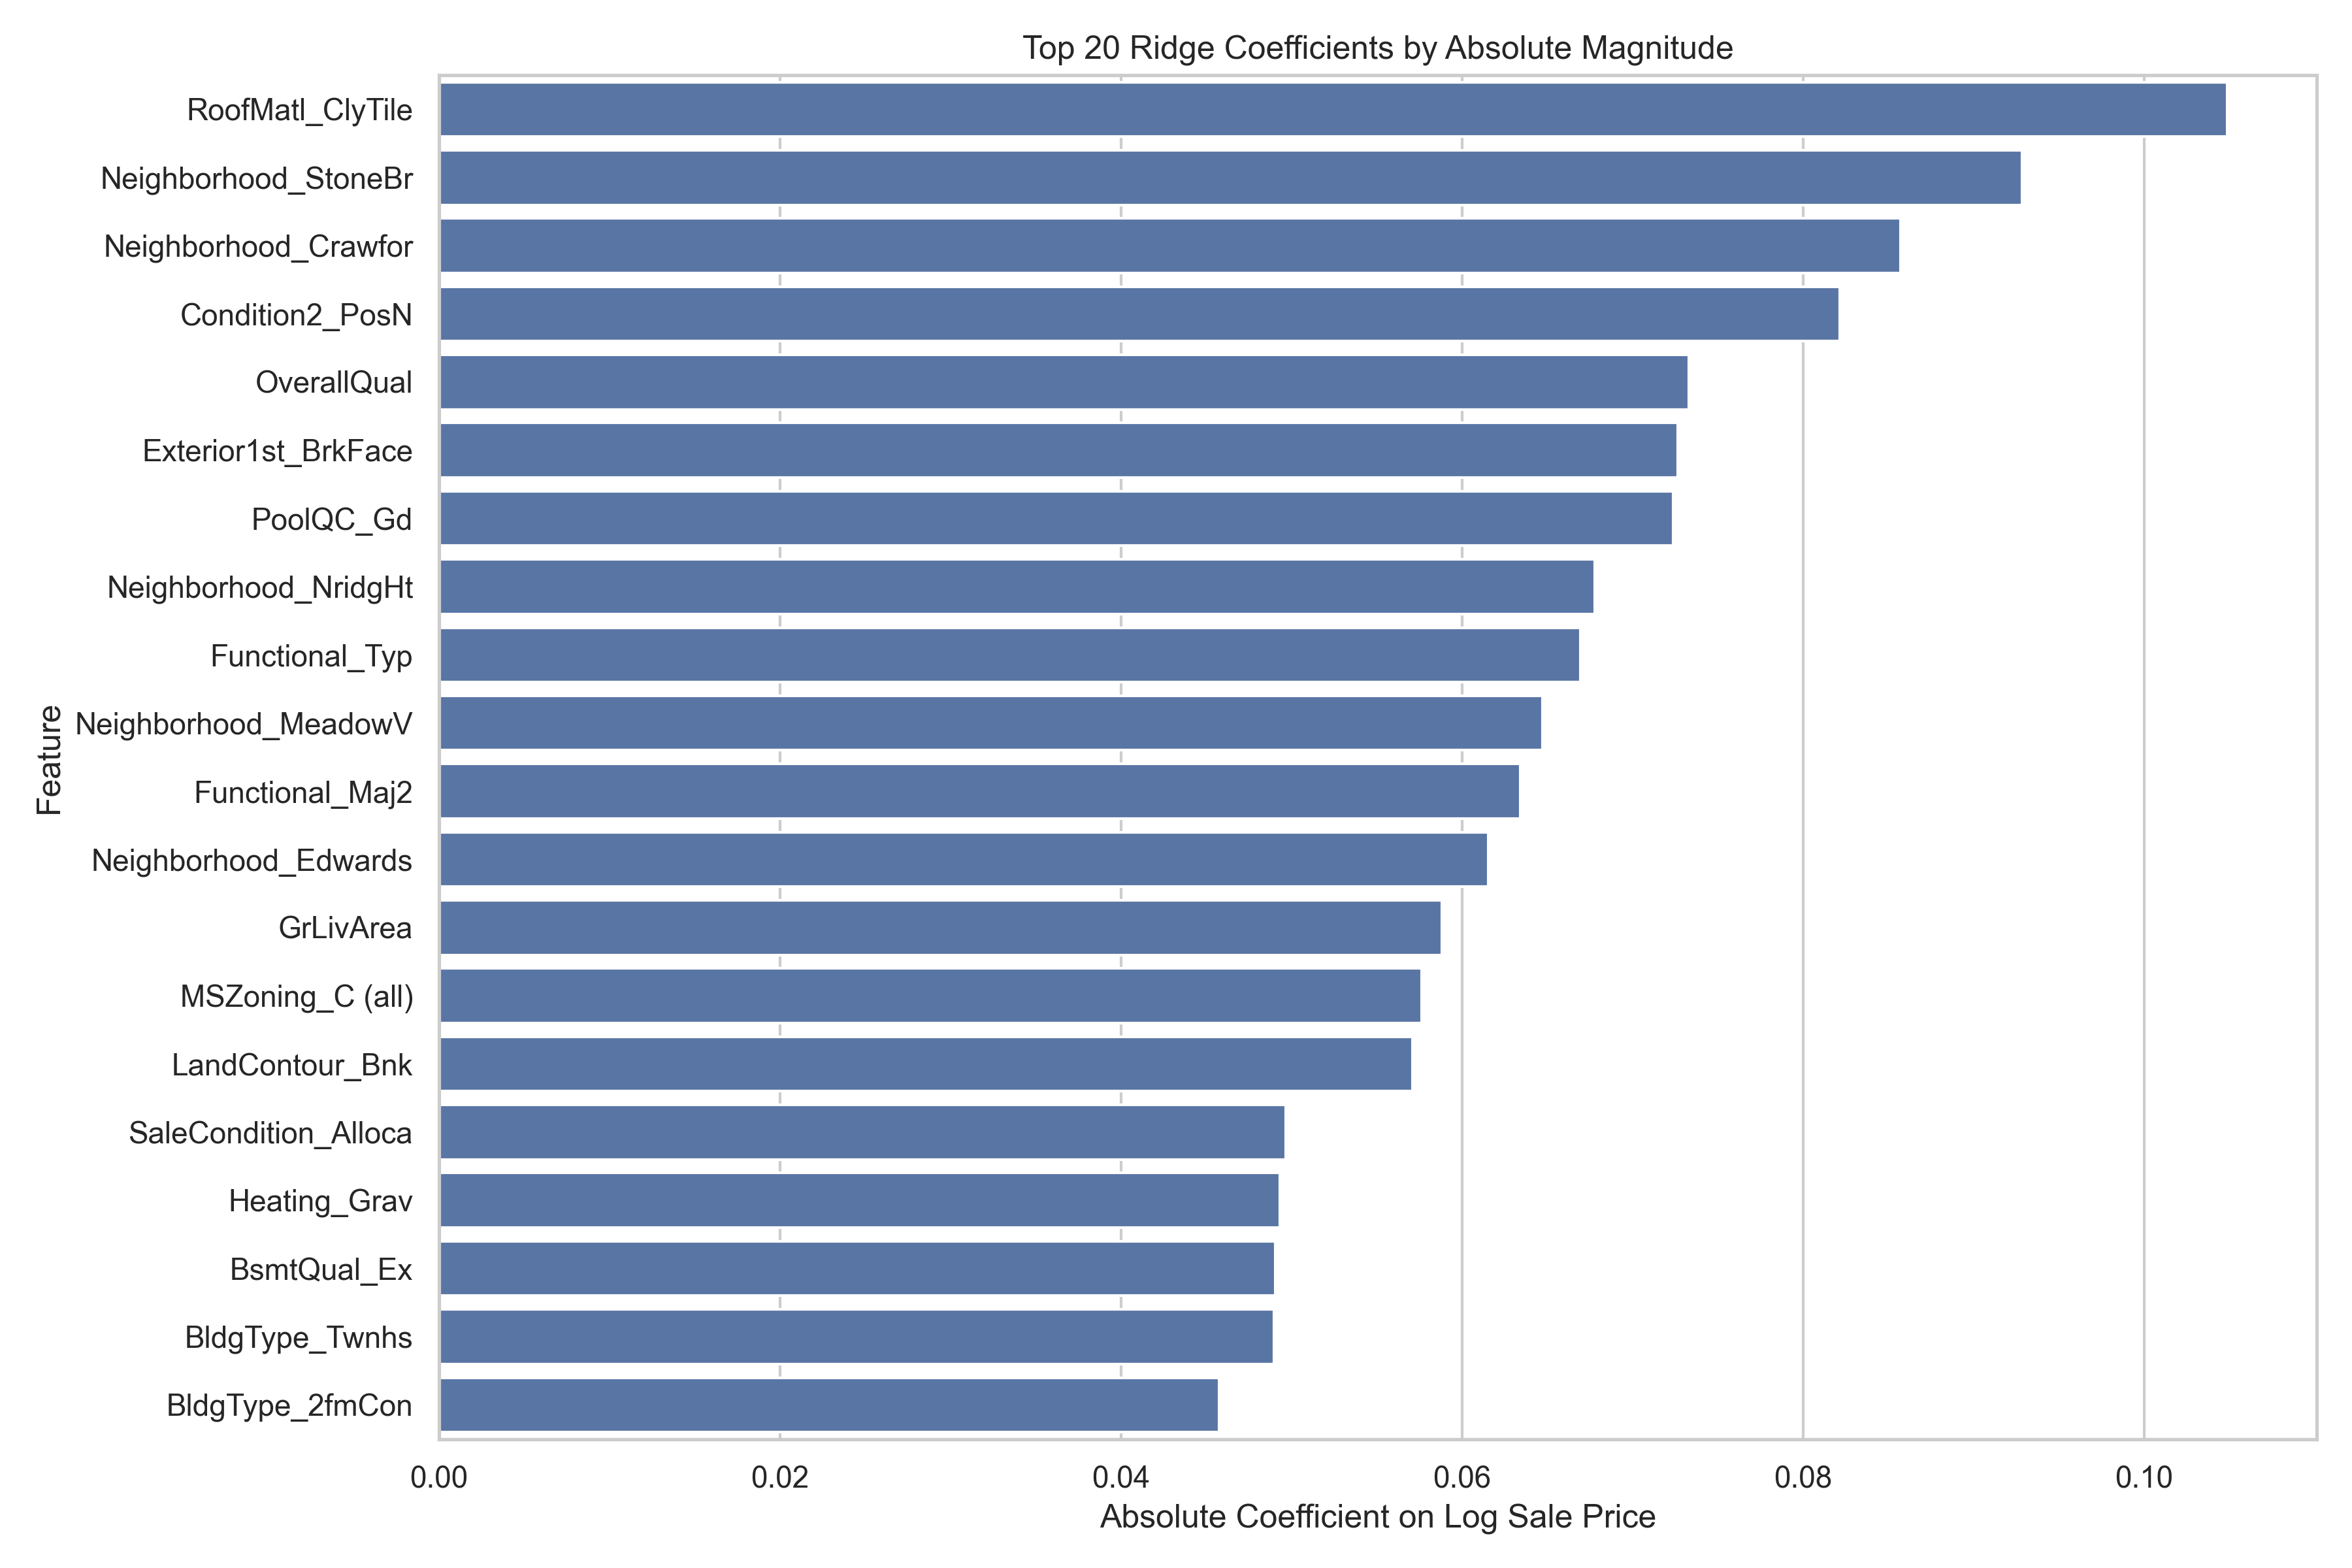

In [18]:
display(Image(filename=FIGURES_DIR / "top_absolute_ridge_coefficients.png"))

## Interpretation Caveat

Ridge coefficients are useful for interpretation, but they are not causal estimates.

For scaled numerical variables, coefficients represent the association of a one-standard-deviation increase with log-transformed sale price.

For categorical variables, coefficients represent regularized associations relative to the encoded reference structure.

## Key Findings

- All machine learning models strongly outperformed the median baseline.
- Linear Regression performed best on a single validation split, but cross-validation showed it was unstable.
- Random Forest was selected as the final predictive model because it had the best cross-validation RMSE stability.
- The model performs well for typical properties but has larger errors for expensive or atypical homes.
- Ridge coefficients suggest that neighborhood, overall quality, living area, basement quality, garage capacity, and kitchen quality are important price-related features.
- Model interpretation should be treated as association, not causation.

## Business Recommendations

- Use the model as a pricing support tool, not as an automatic valuation authority.
- Review high-error predictions manually, especially for luxury or atypical properties.
- Combine model outputs with local market knowledge before making pricing decisions.
- Use Ridge interpretation to communicate key value drivers to non-technical stakeholders.
- Improve the dataset with location granularity, renovation details, market timing, and comparable sales if available.

## Limitations

- The dataset is small for a high-dimensional regression problem.
- The Kaggle test set does not include true sale prices, so validation relies on the training data split and cross-validation.
- One-hot encoded categorical variables can make linear models unstable.
- The model does not include macroeconomic conditions, exact geographic coordinates, school district quality, or market demand signals.
- The model should not be interpreted causally.